# GCCR Slack Network Analysis

Equity and inclusivity analysis using directed interaction network (@ mentions + reactions). Produces `outputs/f-slack-equity.png`, `outputs/f-slack-inclusivity.png`, and `outputs/slack-network-metrics.csv`.

## Setup

In [1]:
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")


In [2]:
# Install required packages
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "networkx", "python-louvain", "geopandas", "seaborn"], check=True)


CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'networkx', 'python-louvain', 'geopandas', 'seaborn'], returncode=0)

In [3]:
import os
import json
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from networkx.algorithms import community as nx_comm
import warnings
warnings.filterwarnings("ignore")

# Mako palette matching R: begin=0.3, end=0.9, direction=-1, alpha=0.9
_mako_full = sns.color_palette("mako", as_cmap=True)
_n = 256
_colors = _mako_full(np.linspace(0.9, 0.3, _n))
_colors[:, 3] = 0.9
MAKO = LinearSegmentedColormap.from_list("mako_r_narrow", _colors, N=_n)
C_LOW  = "#A8E1BC"
C_HIGH = "#414081"
C_MID  = "#3DB4AD"
C_MID2 = "#357BA2"
C_4    = ["#A8E1BC", "#3DB4AD", "#357BA2", "#414081"]


In [4]:
df = pd.read_csv(os.path.join("data", "slack-analysis.csv"))
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["reactions"] = df["reactions"].apply(lambda x: json.loads(x) if pd.notna(x) else [])

# Total user counts from full file (all 660)
total_users   = df["id"].nunique()
inactive_users = df[df["active"] == False]["id"].nunique()

# df = active users only for all message operations
df = df[df["active"] == True].copy()

print(f'Total workspace users: {total_users:,}')
print(f'Active users:          {df["id"].nunique():,}')
print(f'Inactive users:        {inactive_users:,}')
print(f'Total messages:        {len(df):,}')

print(df.shape) 
print(df.columns.tolist())


Total workspace users: 660
Active users:          600
Inactive users:        60
Total messages:        22,309
(22309, 13)
['id', 'role', 'channel', 'date', 'ts', 'thread_ts', 'subtype', 'reactions', 'word_count', 'has_mention', 'has_url', 'active', 'mentions']


## Filter Justification

In [5]:
# Edge weight distribution — justifies weight >= 3 filter
# Build temporary graph from thread co-participation for diagnostic only
msg_counts_diag = df[df["active"]==True].groupby("id").size()
active_users_diag = set(msg_counts_diag[msg_counts_diag >= 5].index)

G_diag = nx.Graph()
threaded_diag = df[df["thread_ts"].notna() & df["id"].isin(active_users_diag)]
for _, thread_msgs in threaded_diag.groupby("thread_ts"):
    participants = list(set(thread_msgs["id"].tolist()))
    if len(participants) > 1:
        for i in range(len(participants)):
            for j in range(i+1, len(participants)):
                u, v = participants[i], participants[j]
                if G_diag.has_edge(u, v):
                    G_diag[u][v]["weight"] = G_diag[u][v].get("weight", 0) + 1
                else:
                    G_diag.add_edge(u, v, weight=1)

# Add role and country to G_diag nodes
user_role    = df[df["active"]==True].groupby("id")["role"].first().to_dict()
for node in G_diag.nodes():
    G_diag.nodes[node]["role"]    = user_role.get(node, "Unknown")

weights = [d.get("weight", 1) for _, _, d in G_diag.edges(data=True)]
print(f"Total edges: {len(weights)}")
print(f"Weight = 1: {sum(1 for w in weights if w == 1)} ({sum(1 for w in weights if w == 1)/len(weights)*100:.1f}%)")
print(f"Weight >= 2: {sum(1 for w in weights if w >= 2)} ({sum(1 for w in weights if w >= 2)/len(weights)*100:.1f}%)")
print(f"Weight >= 3: {sum(1 for w in weights if w >= 3)} ({sum(1 for w in weights if w >= 3)/len(weights)*100:.1f}%)")
print(f"Mean: {np.mean(weights):.2f}, Median: {np.median(weights):.2f}, Max: {max(weights)}")
print()
# Message count thresholds
msg_counts_diag2 = df[df["active"]==True].groupby("id").size()
for min_msgs in [3, 5, 10, 20]:
    users = set(msg_counts_diag2[msg_counts_diag2 >= min_msgs].index)
    print(f"Messages >= {min_msgs}: {len(users)} users ({len(users)/600*100:.1f}% of active)")


Total edges: 7276
Weight = 1: 4665 (64.1%)
Weight >= 2: 2611 (35.9%)
Weight >= 3: 1392 (19.1%)
Mean: 2.25, Median: 1.00, Max: 63

Messages >= 3: 418 users (69.7% of active)
Messages >= 5: 347 users (57.8% of active)
Messages >= 10: 229 users (38.2% of active)
Messages >= 20: 149 users (24.8% of active)


## Combined Filter Diagnostic

In [6]:
# Combined filter: >= 5 messages AND edge weight >= 3
msg_counts = df[df["active"]==True].groupby("id").size()
msg_5_users = set(msg_counts[msg_counts >= 5].index)
H5 = G_diag.subgraph([n for n in G_diag.nodes() if n in msg_5_users]).copy()
H5_filtered = nx.Graph()
for u, v, d in H5.edges(data=True):
    if d.get("weight", 1) >= 3:
        H5_filtered.add_edge(u, v, **d)
for node, data in H5.nodes(data=True):
    if node in H5_filtered:
        H5_filtered.nodes[node].update(data)
print(f"Users >=5 msgs + edge weight >=3: {H5_filtered.number_of_nodes()} nodes, {H5_filtered.number_of_edges()} edges")
print(f"Components: {nx.number_connected_components(H5_filtered)}")
lcc5 = H5_filtered.subgraph(max(nx.connected_components(H5_filtered), key=len))
print(f"LCC: {lcc5.number_of_nodes()} nodes ({lcc5.number_of_nodes()/H5_filtered.number_of_nodes()*100:.0f}%)")
role_counts = {}
for n in H5_filtered.nodes():
    role = user_role.get(n, "Unknown")
    role_counts[role] = role_counts.get(role, 0) + 1
for role, count in sorted(role_counts.items()):
    print(f"{role}: {count}")


Users >=5 msgs + edge weight >=3: 163 nodes, 1392 edges
Components: 1
LCC: 163 nodes (100%)
Leadership: 12
Member: 151


## Network Metrics

Builds directed interaction graph and computes all agreed metrics: attention getting, outgoing total, interaction, attention seeking, reach. Gini reported by role.

In [7]:
# ---------------------------------------------------------------
# Build clean directed interaction network
# Edges: @ mentions + reactions only (unambiguous directed interactions)
# ---------------------------------------------------------------
import re
import matplotlib.colors as mcolors
from networkx.algorithms import community as nx_comm
from collections import Counter

# User filter: >= 5 messages
msg_counts   = df[df["active"]==True].groupby("id").size()
active_users = set(msg_counts[msg_counts >= 5].index)
print(f"Users >= 5 messages: {len(active_users)}")

# Build directed interaction graph (@ mentions + reactions only)
DG = nx.DiGraph()
for node in active_users:
    role    = df[df["id"]==node]["role"].iloc[0]    if len(df[df["id"]==node]) > 0 else "Unknown"
    DG.add_node(node, role=role)

# @ mention edges
mention_pattern = re.compile(r"<@(User_\d+)>")
for _, row in df[df["has_mention"]==True].iterrows():
    sender = row["id"]
    if sender not in active_users:
        continue
    for mentioned in [m for m in str(row.get("mentions", "")).split(",") if m]:
        if mentioned != sender and mentioned in active_users:
            if DG.has_edge(sender, mentioned):
                DG[sender][mentioned]["mentions"] = DG[sender][mentioned].get("mentions", 0) + 1
                DG[sender][mentioned]["weight"]   = DG[sender][mentioned].get("weight",   0) + 1
            else:
                DG.add_edge(sender, mentioned, mentions=1, reactions=0, weight=1)

# Reaction edges (reactor -> post author)
for _, row in df.iterrows():
    if not isinstance(row["reactions"], list) or not row["reactions"]:
        continue
    author = row["id"]
    if author not in active_users:
        continue
    for reaction in row["reactions"]:
        for reactor in reaction.get("users", []):
            if reactor != author and reactor in active_users:
                if DG.has_edge(reactor, author):
                    DG[reactor][author]["reactions"] = DG[reactor][author].get("reactions", 0) + 1
                    DG[reactor][author]["weight"]    = DG[reactor][author].get("weight",    0) + 1
                else:
                    DG.add_edge(reactor, author, mentions=0, reactions=1, weight=1)

print(f"Directed graph: {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges")

# ---------------------------------------------------------------
# Compute node metrics using agreed terms
# ---------------------------------------------------------------

# Attention getting: total @ received + total reactions received
# = total weighted incoming interactions
attention_getting = {}
for node in DG.nodes():
    total_in = sum(d.get("weight", 1) for _, _, d in DG.in_edges(node, data=True))
    attention_getting[node] = total_in

# Outgoing total: total @ given + total reactions given
outgoing_total = {}
for node in DG.nodes():
    total_out = sum(d.get("weight", 1) for _, _, d in DG.out_edges(node, data=True))
    outgoing_total[node] = total_out

# Interaction: incoming / (incoming + outgoing), ranges 0-1
# High = broadcaster, 0.5 = balanced, low = receiver
interaction = {}
for node in DG.nodes():
    total = attention_getting[node] + outgoing_total[node]
    interaction[node] = attention_getting[node] / total if total > 0 else 0.5

# Attention seeking: (@ given in unique threads + reactions given) / n_unique_targets
# High with few targets = clique, high with many = distributed connector
attention_seeking = {}
for node in DG.nodes():
    unique_targets = set(DG.successors(node))
    n_unique = len(unique_targets)
    # @ given in unique threads = unique people @-mentioned
    mentions_out = sum(1 for _, v, d in DG.out_edges(node, data=True) if d.get("mentions", 0) > 0)
    reactions_out = sum(d.get("reactions", 0) for _, _, d in DG.out_edges(node, data=True))
    attention_seeking[node] = (mentions_out + reactions_out) / n_unique if n_unique > 0 else 0

# Reach: unique people you engaged / unique people who engaged you
# High = reciprocate your engagers, low = engage different people
reach = {}
for node in DG.nodes():
    unique_engaged_you  = set(DG.predecessors(node))
    unique_you_engaged  = set(DG.successors(node))
    reach[node] = len(unique_you_engaged) / len(unique_engaged_you) if unique_engaged_you else 0

# Store all metrics as node attributes
nx.set_node_attributes(DG, attention_getting, "attention_getting")
nx.set_node_attributes(DG, outgoing_total,    "outgoing_total")
nx.set_node_attributes(DG, interaction,       "interaction")
nx.set_node_attributes(DG, attention_seeking, "attention_seeking")
nx.set_node_attributes(DG, reach,             "reach")

# Gini on attention getting across all users
def gini_coeff(values):
    values = np.array(sorted(values), dtype=float)
    if len(values) == 0 or values.sum() == 0:
        return 0
    n = len(values)
    cumsum = np.cumsum(values)
    return (2 * np.sum(np.arange(1, n+1) * values)) / (n * cumsum[-1]) - (n+1)/n

all_ag = list(attention_getting.values())
lead_ag = [attention_getting[n] for n, d in DG.nodes(data=True) if d.get("role")=="Leadership"]
memb_ag = [attention_getting[n] for n, d in DG.nodes(data=True) if d.get("role")=="Member"]
print(f"\n=== Network Statistics ===")
print(f"Nodes:         {DG.number_of_nodes()}")
print(f"Edges:         {DG.number_of_edges()}")
print(f"Density:       {nx.density(DG):.4f}")
print(f"Reciprocity:   {nx.overall_reciprocity(DG):.4f}")
print(f"\nGini (attention getting, all users):    {gini_coeff(all_ag):.3f}")
print(f"Gini (attention getting, Leadership):   {gini_coeff(lead_ag):.3f}")
print(f"Gini (attention getting, Member):       {gini_coeff(memb_ag):.3f}")

print(f"\n=== Metrics by Role ===")
metrics_rows = []
for role in ["Leadership", "Member"]:
    nodes = [n for n, d in DG.nodes(data=True) if d.get("role") == role]
    ag    = [attention_getting[n]  for n in nodes]
    ot    = [outgoing_total[n]     for n in nodes]
    inter = [interaction[n]        for n in nodes]
    aseek = [attention_seeking[n]  for n in nodes]
    rea   = [reach[n]              for n in nodes]
    print(f"\n{role} (n={len(nodes)}):")
    print(f"  Attention getting:  mean={np.mean(ag):.1f}, SD={np.std(ag):.1f}")
    print(f"  Outgoing total:     mean={np.mean(ot):.1f}, SD={np.std(ot):.1f}")
    print(f"  Interaction:        mean={np.mean(inter):.3f}, SD={np.std(inter):.3f}")
    print(f"  Attention seeking:  mean={np.mean(aseek):.3f}, SD={np.std(aseek):.3f}")
    print(f"  Reach:              mean={np.mean(rea):.3f}, SD={np.std(rea):.3f}")
    metrics_rows.append({
        "Role": role, "N": len(nodes),
        "Attention_Getting_Mean": round(np.mean(ag), 2),
        "Attention_Getting_SD":   round(np.std(ag), 2),
        "Interaction_Mean":       round(np.mean(inter), 3),
        "Interaction_SD":         round(np.std(inter), 3),
        "Attention_Seeking_Mean": round(np.mean(aseek), 3),
        "Attention_Seeking_SD":   round(np.std(aseek), 3),
        "Reach_Mean":             round(np.mean(rea), 3),
        "Reach_SD":               round(np.std(rea), 3),
    })

Users >= 5 messages: 347
Directed graph: 347 nodes, 4352 edges

=== Network Statistics ===
Nodes:         347
Edges:         4352
Density:       0.0362
Reciprocity:   0.5469

Gini (attention getting, all users):    0.833
Gini (attention getting, Leadership):   0.577
Gini (attention getting, Member):       0.758

=== Metrics by Role ===

Leadership (n=12):
  Attention getting:  mean=844.7, SD=1111.8
  Outgoing total:     mean=479.8, SD=384.1
  Interaction:        mean=0.641, SD=0.174
  Attention seeking:  mean=3.433, SD=2.128
  Reach:              mean=0.789, SD=0.327

Member (n=335):
  Attention getting:  mean=37.7, SD=85.2
  Outgoing total:     mean=50.8, SD=154.2
  Interaction:        mean=0.560, SD=0.274
  Attention seeking:  mean=1.855, SD=2.023
  Reach:              mean=0.923, SD=1.146


## Power Distribution: Personal Gini & Reciprocity

Network Gini (in_degree): 0.670
Gini Leadership: 0.339
Gini Member:     0.623

Personal Gini — Mean: 0.333, Median: 0.347
High Gini (>0.7): 0 users
Low Gini (<0.3):  111 users

By quartile:
  Q1 low: n=71, Leadership=2, Member=69, mean in_degree=3.6, mean attention_getting=5.042
  Q2: n=63, Leadership=0, Member=63, mean in_degree=7.8, mean attention_getting=15.159
  Q3: n=65, Leadership=0, Member=65, mean in_degree=13.5, mean attention_getting=35.569
  Q4 high: n=66, Leadership=10, Member=56, mean in_degree=40.8, mean attention_getting=289.091


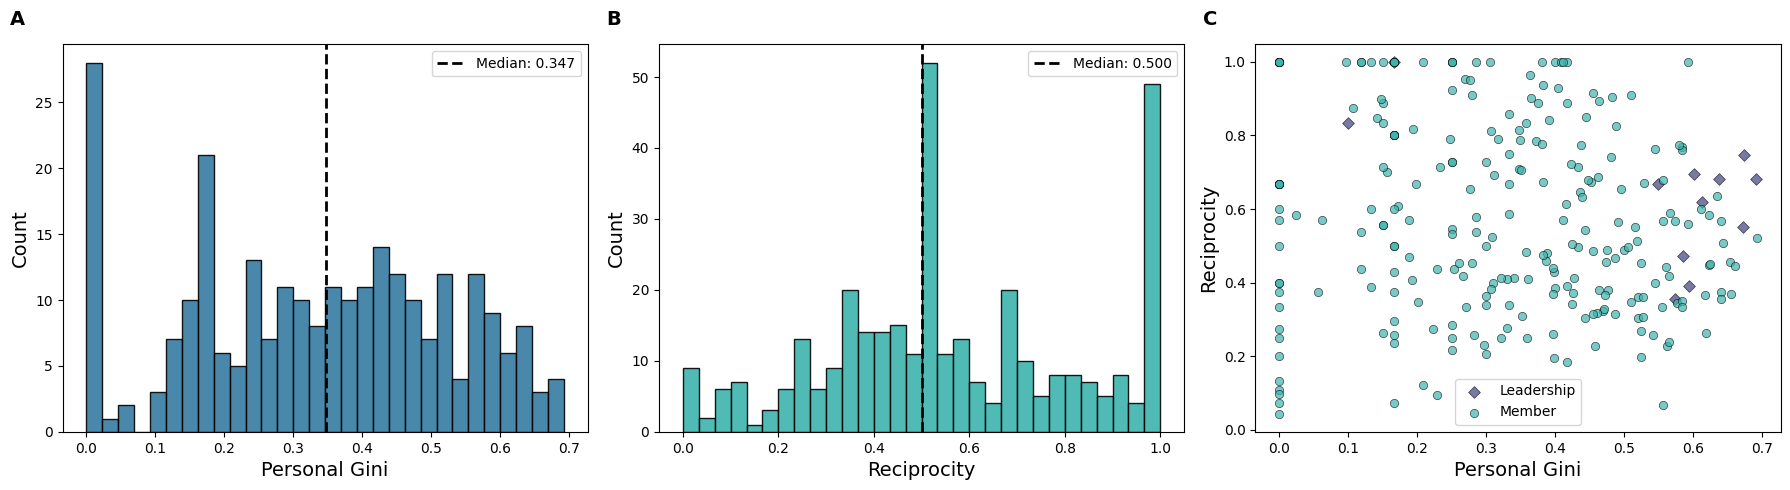

Saved: artifacts/slack-explore-gini-reciprocity.png


In [8]:
def gini_coeff(values):
    values = np.array(sorted(values), dtype=float)
    if len(values) == 0 or values.sum() == 0:
        return 0
    n = len(values)
    cumsum = np.cumsum(values)
    return (2 * np.sum(np.arange(1, n+1) * values)) / (n * cumsum[-1]) - (n+1)/n

# Overall network Gini
in_degrees = [DG.in_degree(n) for n in DG.nodes()]
print(f"Network Gini (in_degree): {gini_coeff(in_degrees):.3f}")
lead_in = [DG.in_degree(n) for n in DG.nodes() if DG.nodes[n].get("role")=="Leadership"]
memb_in = [DG.in_degree(n) for n in DG.nodes() if DG.nodes[n].get("role")=="Member"]
print(f"Gini Leadership: {gini_coeff(lead_in):.3f}")
print(f"Gini Member:     {gini_coeff(memb_in):.3f}")
print()

# Personal Gini per user
personal_gini = []
for node in DG.nodes():
    in_weights = [d.get("weight", 1) for _, _, d in DG.in_edges(node, data=True)]
    g = np.nan if len(in_weights) < 2 else gini_coeff(in_weights)
    personal_gini.append({
        "id": node,
        "role": DG.nodes[node].get("role"),
        "personal_gini": g,
        "in_degree": DG.in_degree(node),
        "attention_getting": DG.nodes[node].get("attention_getting", 0),
        "interaction": DG.nodes[node].get("interaction", 0)
    })

gini_df = pd.DataFrame(personal_gini).dropna()
print(f"Personal Gini — Mean: {gini_df["personal_gini"].mean():.3f}, Median: {gini_df["personal_gini"].median():.3f}")
print(f"High Gini (>0.7): {(gini_df["personal_gini"]>0.7).sum()} users")
print(f"Low Gini (<0.3):  {(gini_df["personal_gini"]<0.3).sum()} users")
print()

# Quartile breakdown
gini_df["gini_quartile"] = pd.qcut(gini_df["personal_gini"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
print("By quartile:")
for q in ["Q1 low", "Q2", "Q3", "Q4 high"]:
    subset = gini_df[gini_df["gini_quartile"] == q]
    lead_n = (subset["role"] == "Leadership").sum()
    memb_n = (subset["role"] == "Member").sum()
    print(f"  {q}: n={len(subset)}, Leadership={lead_n}, Member={memb_n}, "
          f"mean in_degree={subset["in_degree"].mean():.1f}, "
          f"mean attention_getting={subset["attention_getting"].mean():.3f}")

# Gini/reciprocity exploratory figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(gini_df["personal_gini"], bins=30, color="#357BA2", alpha=0.9, edgecolor="black")
axes[0].axvline(gini_df["personal_gini"].median(), color="black", linestyle="--", linewidth=2,
                label=f'Median: {gini_df["personal_gini"].median():.3f}')
axes[0].set_xlabel("Personal Gini", fontsize=14)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].legend()
axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes, fontsize=14, fontweight="bold")

recip_vals = [DG.nodes[n].get("interaction", 0) for n in DG.nodes()]
axes[1].hist(recip_vals, bins=30, color="#3DB4AD", alpha=0.9, edgecolor="black")
axes[1].axvline(np.median(recip_vals), color="black", linestyle="--", linewidth=2,
                label=f"Median: {np.median(recip_vals):.3f}")
axes[1].set_xlabel("Reciprocity", fontsize=14)
axes[1].set_ylabel("Count", fontsize=14)
axes[1].legend()
axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes, fontsize=14, fontweight="bold")

for role, color, marker in [("Leadership", "#414081", "D"), ("Member", "#3DB4AD", "o")]:
    subset = gini_df[gini_df["role"] == role]
    recip_subset = [DG.nodes[n].get("interaction", 0) for n in subset["id"]]
    axes[2].scatter(subset["personal_gini"], recip_subset,
                   c=color, marker=marker, alpha=0.7, label=role,
                   edgecolors="black", linewidths=0.5)
axes[2].set_xlabel("Personal Gini", fontsize=14)
axes[2].set_ylabel("Reciprocity", fontsize=14)
axes[2].legend()
axes[2].text(-0.1, 1.05, "C", transform=axes[2].transAxes, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("artifacts", "slack-explore-gini-reciprocity.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: artifacts/slack-explore-gini-reciprocity.png")


## Map 1: Equity

Node size = attention getting (log scale, p95 cap). Node color = reach (3 breaks: low/mid/high). Shape = role. Story: who accumulates attention AND has broad network access?

Computing layout...


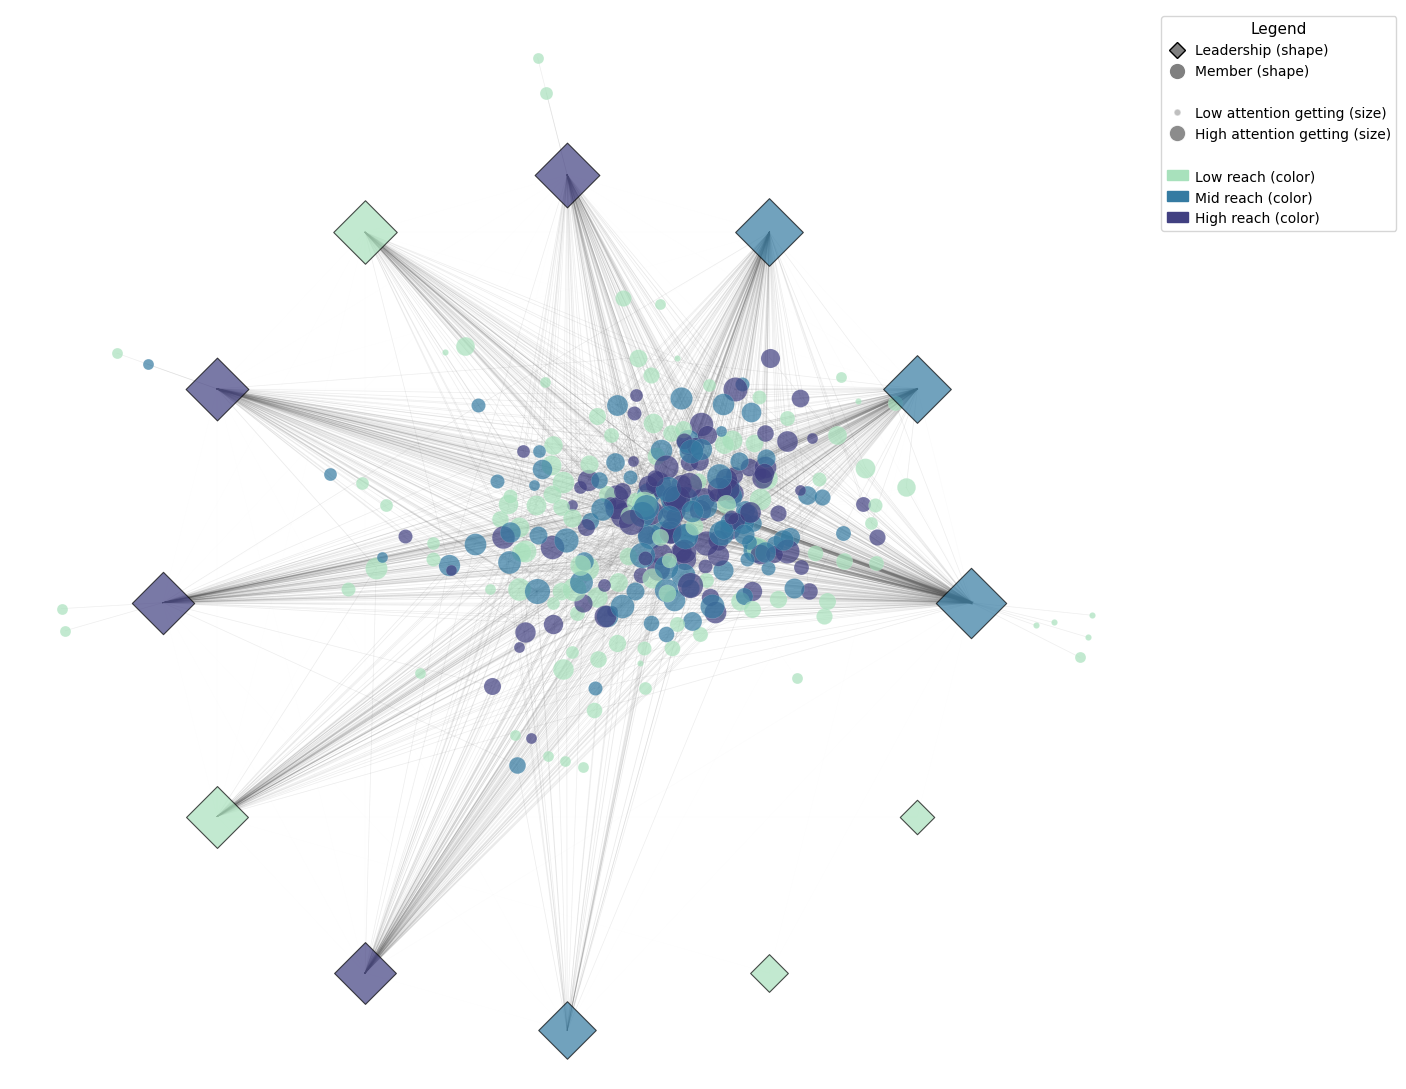

Saved: outputs/f-slack-equity.png
Caption: Node size = attention getting | Node color = reach (3 breaks: low/mid/high) | Shape = role


In [9]:
# Shared setup
import math
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Undirected graph for layout
UDG = nx.Graph()
for u, v, d in DG.edges(data=True):
    if UDG.has_edge(u, v):
        UDG[u][v]["weight"] += d.get("weight", 1)
    else:
        UDG.add_edge(u, v, weight=d.get("weight", 1))
for node, data in DG.nodes(data=True):
    if node in UDG:
        UDG.nodes[node].update(data)
UDG.remove_nodes_from(list(nx.isolates(UDG)))

# Fixed leadership ring, members spring layout
import math
lead_nodes_tmp = [n for n, d in DG.nodes(data=True) if d.get("role") == "Leadership" and n in UDG]
fixed_pos = {}
for idx, node in enumerate(sorted(lead_nodes_tmp, key=lambda n: -attention_getting.get(n, 0))):
    angle = 2 * math.pi * idx / len(lead_nodes_tmp)
    fixed_pos[node] = (3.0 * math.cos(angle), 3.0 * math.sin(angle))
print("Computing layout...")
pos = nx.spring_layout(UDG, weight="weight", seed=42, k=0.2,
                       pos=fixed_pos, fixed=list(fixed_pos.keys()),
                       iterations=200)

# Node lists
lead_nodes = [n for n, d in DG.nodes(data=True) if d.get("role") == "Leadership" and n in pos]
memb_nodes = [n for n, d in DG.nodes(data=True) if d.get("role") == "Member" and n in pos]
all_nodes  = lead_nodes + memb_nodes

# Edge lists
edge_list = [(u, v, d) for u, v, d in UDG.edges(data=True) if u in pos and v in pos]
max_w = max((d.get("weight", 1) for _, _, d in edge_list), default=1)

# Helper: log sizes capped at p95
def get_sizes(metric, nodes, base, scale):
    vals = [metric.get(n, 0) for n in nodes]
    cap = float(np.percentile(vals, 95))
    return [base + np.log1p(min(metric.get(n, 0), cap)) * scale for n in nodes]

# Helper: 3-break colors
MAKO_3 = ["#A8E1BC", "#357BA2", "#414081"]  # light, mid, dark
def breaks_3(metric, nodes):
    vals = np.array([metric.get(n, 0) for n in nodes])
    p33 = np.percentile(vals, 33)
    p67 = np.percentile(vals, 67)
    return [MAKO_3[0] if metric.get(n,0) <= p33
            else MAKO_3[1] if metric.get(n,0) <= p67
            else MAKO_3[2] for n in nodes]

# Helper: 4-break colors
MAKO_4 = ["#A8E1BC", "#3DB4AD", "#357BA2", "#414081"]
def breaks_4(metric, nodes):
    vals = np.array([metric.get(n, 0) for n in nodes])
    p25, p50, p75 = np.percentile(vals, [25, 50, 75])
    return [MAKO_4[0] if metric.get(n,0) <= p25
            else MAKO_4[1] if metric.get(n,0) <= p50
            else MAKO_4[2] if metric.get(n,0) <= p75
            else MAKO_4[3] for n in nodes]

def draw_nodes(ax, nodes, sizes, colors, marker, zorder):
    for node, size, color in zip(nodes, sizes, colors):
        ec = "black" if marker == "D" else "white"
        lw = 0.8 if marker == "D" else 0.1
        ax.scatter(pos[node][0], pos[node][1], s=size, c=color,
                   marker=marker, alpha=0.7, linewidths=lw,
                   edgecolors=ec, zorder=zorder)

role_handles = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="#357BA2",
                  markersize=8, markeredgecolor="black", label="Leadership"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="#357BA2",
                  markersize=12, label="Member"),
]

# Map 1 — Equity: size=attention_getting, color=reach (3 breaks)
lead_sizes1  = get_sizes(attention_getting, lead_nodes, 100, 150)
memb_sizes1  = get_sizes(attention_getting, memb_nodes, 20, 60)
lead_colors1 = breaks_3(reach, lead_nodes)
memb_colors1 = breaks_3(reach, memb_nodes)

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Edges — cross-role spokes more visible
lead_set = set(lead_nodes)
for u, v, d in edge_list:
    w = d.get("weight", 1)
    is_cross = (u in lead_set) != (v in lead_set)
    color = "#555555" if is_cross else "#cccccc"
    alpha = (0.1 + (w/max_w)*0.4) if is_cross else (0.03 + (w/max_w)*0.12)
    lw    = (0.5 + (w/max_w)*2.0) if is_cross else (0.15 + (w/max_w)*0.5)
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color=color, alpha=alpha, linewidth=lw, zorder=1)

draw_nodes(ax, memb_nodes, memb_sizes1, memb_colors1, "o", 2)
draw_nodes(ax, lead_nodes, lead_sizes1, lead_colors1, "D", 3)

# Combined legend
combined_handles = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="grey",
                  markersize=8, markeredgecolor="black", label="Leadership (shape)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, label="Member (shape)"),
    mpatches.Patch(color="white", label=""),  # spacer
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=5, alpha=0.5, label="Low attention getting (size)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, alpha=0.9, label="High attention getting (size)"),
    mpatches.Patch(color="white", label=""),  # spacer
    mpatches.Patch(color=MAKO_3[0], label="Low reach (color)"),
    mpatches.Patch(color=MAKO_3[1], label="Mid reach (color)"),
    mpatches.Patch(color=MAKO_3[2], label="High reach (color)"),
]
ax.legend(handles=combined_handles, loc="upper left",
          bbox_to_anchor=(1.01, 1), frameon=True,
          fontsize=10, title="Legend", title_fontsize=11, labelcolor="black",
          handlelength=1.5, handletextpad=0.5)
ax.set_axis_off()
plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.savefig(os.path.join("outputs", "f-slack-equity.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/f-slack-equity.png")
print("Caption: Node size = attention getting | Node color = reach (3 breaks: low/mid/high) | Shape = role")


## Map 2: Inclusivity (Two Panel)

Panel A: size=attention seeking, color=reach. Are people connecting broadly or chasing in cliques?

Panel B: size=attention getting, color=interaction ratio, edge opacity=reach. Do those who accumulate attention engage reciprocally and broadly?

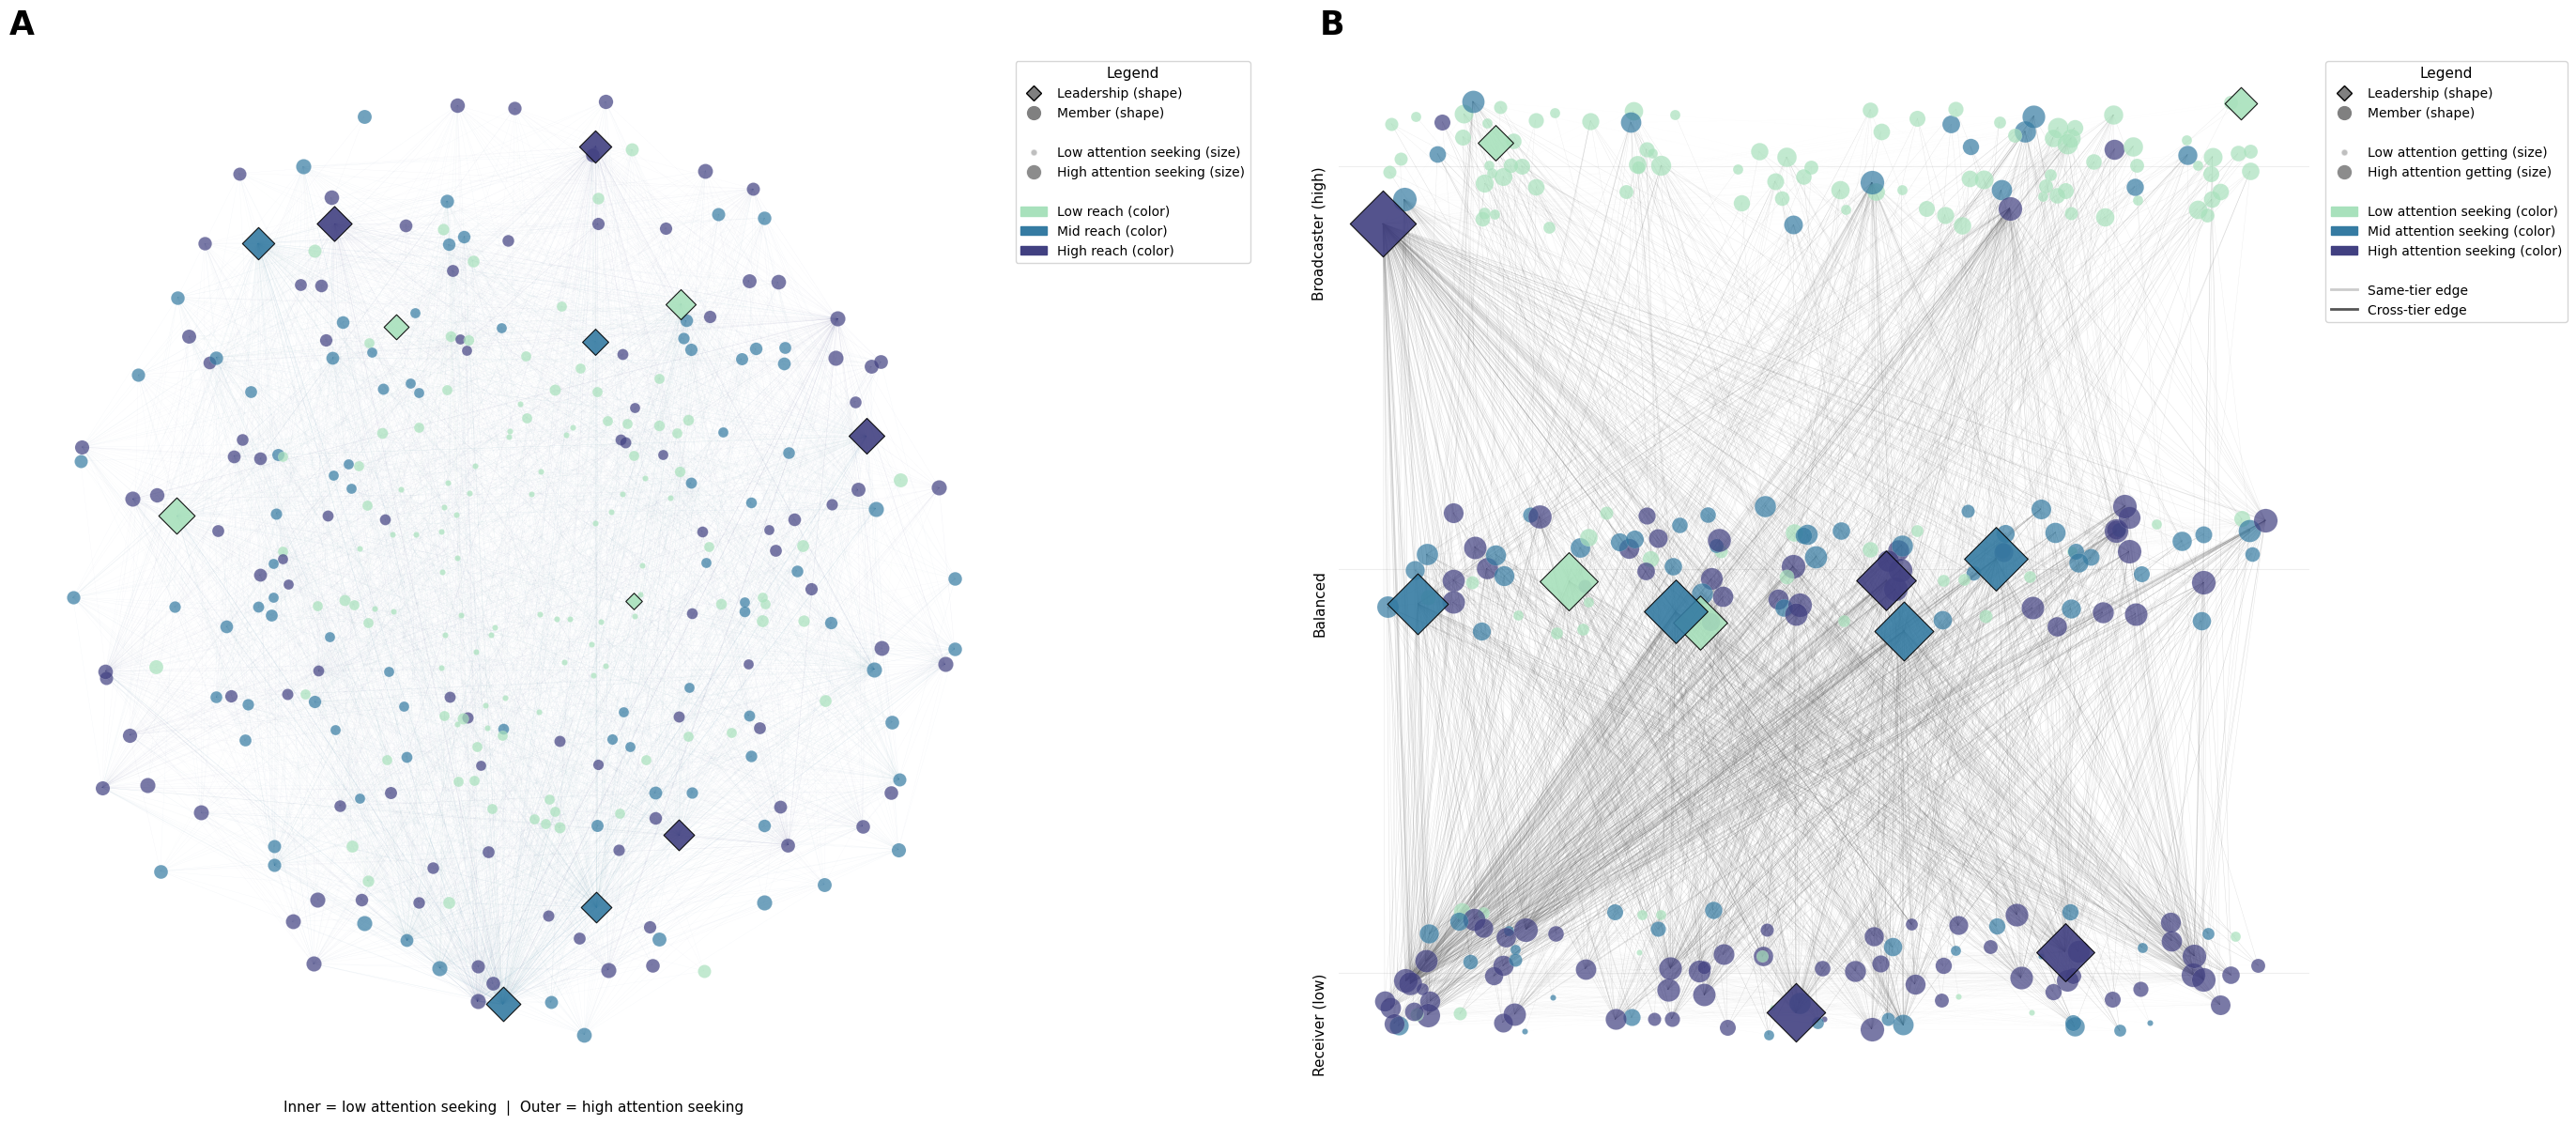

Saved: outputs/f-slack-inclusivity.png


In [10]:
# Map 2 — Inclusivity: manual tiered layouts
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

all_nodes_list = [n for n in DG.nodes() if n in UDG]
lead_nodes_m = [n for n, d in DG.nodes(data=True) if d.get("role") == "Leadership" and n in UDG]
memb_nodes_m = [n for n, d in DG.nodes(data=True) if d.get("role") == "Member" and n in UDG]
max_w = max((d.get("weight", 1) for _, _, d in UDG.edges(data=True)), default=1)

# 3-break colors for both panels
MAKO_3 = ["#A8E1BC", "#357BA2", "#414081"]
def breaks_3(metric, nodes):
    vals = np.array([metric.get(n, 0) for n in nodes])
    p33, p67 = np.percentile(vals, [33, 67])
    return [MAKO_3[0] if metric.get(n,0) <= p33
            else MAKO_3[1] if metric.get(n,0) <= p67
            else MAKO_3[2] for n in nodes]

def breaks_3_val(val, all_vals):
    p33, p67 = np.percentile(all_vals, [33, 67])
    return MAKO_3[0] if val <= p33 else MAKO_3[1] if val <= p67 else MAKO_3[2]

# Reach values for edge coloring in A
reach_all_vals = np.array([reach.get(n, 0) for n in all_nodes_list])
p95_r = float(np.percentile(reach_all_vals, 95))

# Interaction tier for cross-tier detection in B
inter_vals = np.array([interaction.get(n, 0) for n in all_nodes_list])
p33_inter, p67_inter = np.percentile(inter_vals, [33, 67])
def inter_tier(node):
    v = interaction.get(node, 0)
    return 0 if v <= p33_inter else 1 if v <= p67_inter else 2

# ---------------------------------------------------------------
# Tiered layout functions
# ---------------------------------------------------------------
def tiered_radial(nodes, metric, n_tiers=4, jitter=0.15):
    rng = np.random.default_rng(42)
    vals = np.array([metric.get(n, 0) for n in nodes])
    percentiles = np.percentile(vals, np.linspace(0, 100, n_tiers+1))
    pos = {}
    for tier in range(n_tiers):
        tier_nodes = [n for n, v in zip(nodes, vals)
                      if v >= percentiles[tier] and (v < percentiles[tier+1] or tier == n_tiers-1)]
        if not tier_nodes:
            continue
        r = 0.25 + tier * 0.75 / (n_tiers - 1)
        angles = np.linspace(0, 2*np.pi, len(tier_nodes), endpoint=False)
        angles += rng.uniform(0, 2*np.pi/max(len(tier_nodes),1))
        for node, angle in zip(tier_nodes, angles):
            x = r * np.cos(angle) + rng.uniform(-jitter, jitter)
            y = r * np.sin(angle) + rng.uniform(-jitter, jitter)
            pos[node] = (x, y)
    return pos

def tiered_horizontal(nodes, metric, jitter=0.12):
    rng = np.random.default_rng(42)
    vals = np.array([metric.get(n, 0) for n in nodes])
    p33 = np.percentile(vals, 33)
    p67 = np.percentile(vals, 67)
    pos = {}
    tier_y = {0: -0.75, 1: 0.0, 2: 0.75}
    for node, val in zip(nodes, vals):
        tier = 0 if val <= p33 else 1 if val <= p67 else 2
        x = rng.uniform(-1, 1)
        y = tier_y[tier] + rng.uniform(-jitter, jitter)
        pos[node] = (x, y)
    return pos

pos_a = tiered_radial(all_nodes_list, attention_seeking)
pos_b = tiered_horizontal(all_nodes_list, interaction)

# Node sizes
lead_sizes_a = get_sizes(attention_seeking, lead_nodes_m, 80, 150)
memb_sizes_a = get_sizes(attention_seeking, memb_nodes_m, 20, 60)
lead_colors_a = breaks_3(reach, lead_nodes_m)
memb_colors_a = breaks_3(reach, memb_nodes_m)

lead_sizes_b = get_sizes(attention_getting, lead_nodes_m, 100, 150)
memb_sizes_b = get_sizes(attention_getting, memb_nodes_m, 20, 60)
lead_colors_b = breaks_3(attention_seeking, lead_nodes_m)
memb_colors_b = breaks_3(attention_seeking, memb_nodes_m)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# ---------------------------------------------------------------
# Panel A: size=attention seeking, color=reach, edge color=source reach
# ---------------------------------------------------------------
ax = axes[0]
ax.set_facecolor("white")

# Edges colored by source reach
for u, v, d in UDG.edges(data=True):
    if u not in pos_a or v not in pos_a: continue
    w = d.get("weight", 1)
    edge_color = breaks_3_val(reach.get(u, 0), reach_all_vals)
    ax.plot([pos_a[u][0], pos_a[v][0]], [pos_a[u][1], pos_a[v][1]],
            color=edge_color, alpha=0.05 + (w/max_w)*0.2,
            linewidth=0.2 + (w/max_w)*0.8, zorder=1)

for node, size, color in zip(memb_nodes_m, memb_sizes_a, memb_colors_a):
    if node not in pos_a: continue
    ax.scatter(pos_a[node][0], pos_a[node][1], s=size, c=color,
               marker="o", alpha=0.7, linewidths=0.1, edgecolors="white", zorder=2)
for node, size, color in zip(lead_nodes_m, lead_sizes_a, lead_colors_a):
    if node not in pos_a: continue
    ax.scatter(pos_a[node][0], pos_a[node][1], s=size, c=color,
               marker="D", alpha=0.9, linewidths=0.8, edgecolors="black", zorder=3)

# Full legend Panel A
role_handles_a = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="grey",
                  markersize=8, markeredgecolor="black", label="Leadership"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, label="Member"),
]
size_handles_a = [
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=5, alpha=0.7, label="Low attention seeking"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, alpha=0.7, label="High attention seeking"),
]
color_handles_a = [mpatches.Patch(color=MAKO_3[i], label=l)
                   for i, l in enumerate(["Low reach", "Mid reach", "High reach"])]

combined_a = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="grey",
                  markersize=8, markeredgecolor="black", label="Leadership (shape)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, label="Member (shape)"),
    mpatches.Patch(color="white", label=""),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=5, alpha=0.5, label="Low attention seeking (size)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, alpha=0.9, label="High attention seeking (size)"),
    mpatches.Patch(color="white", label=""),
    mpatches.Patch(color=MAKO_3[0], label="Low reach (color)"),
    mpatches.Patch(color=MAKO_3[1], label="Mid reach (color)"),
    mpatches.Patch(color=MAKO_3[2], label="High reach (color)"),
]
ax.legend(handles=combined_a, loc="upper left",
          bbox_to_anchor=(1.01, 1), frameon=True,
          fontsize=10, title="Legend", title_fontsize=11, labelcolor="black")
ax.text(0.5, -0.03, "Inner = low attention seeking  |  Outer = high attention seeking",
        transform=ax.transAxes, fontsize=11, ha="center", color="black")
ax.text(-0.02, 1.02, "A", transform=ax.transAxes, fontsize=25, fontweight="bold")
ax.set_axis_off()

# ---------------------------------------------------------------
# Panel B: size=attention getting, color=interaction (3 breaks)
# Same-tier edges = light grey, cross-tier = dark grey, opacity=reach
# ---------------------------------------------------------------
ax = axes[1]
ax.set_facecolor("white")

# Same-tier edges first (light grey)
for u, v, d in UDG.edges(data=True):
    if u not in pos_b or v not in pos_b: continue
    if inter_tier(u) != inter_tier(v): continue
    w = d.get("weight", 1)
    r_avg = (min(reach.get(u,0), p95_r) + min(reach.get(v,0), p95_r)) / (2 * max(p95_r, 0.001))
    ax.plot([pos_b[u][0], pos_b[v][0]], [pos_b[u][1], pos_b[v][1]],
            color="#cccccc", alpha=0.03 + r_avg*0.15,
            linewidth=0.15 + (w/max_w)*0.5, zorder=1)

# Cross-tier edges (dark grey, more visible)
for u, v, d in UDG.edges(data=True):
    if u not in pos_b or v not in pos_b: continue
    if inter_tier(u) == inter_tier(v): continue
    w = d.get("weight", 1)
    r_avg = (min(reach.get(u,0), p95_r) + min(reach.get(v,0), p95_r)) / (2 * max(p95_r, 0.001))
    ax.plot([pos_b[u][0], pos_b[v][0]], [pos_b[u][1], pos_b[v][1]],
            color="#555555", alpha=0.05 + r_avg*0.3,
            linewidth=0.3 + (w/max_w)*1.0, zorder=2)

for node, size, color in zip(memb_nodes_m, memb_sizes_b, memb_colors_b):
    if node not in pos_b: continue
    ax.scatter(pos_b[node][0], pos_b[node][1], s=size, c=color,
               marker="o", alpha=0.7, linewidths=0.1, edgecolors="white", zorder=3)
for node, size, color in zip(lead_nodes_m, lead_sizes_b, lead_colors_b):
    if node not in pos_b: continue
    ax.scatter(pos_b[node][0], pos_b[node][1], s=size, c=color,
               marker="D", alpha=0.9, linewidths=0.8, edgecolors="black", zorder=4)

# Tier labels — rotated 90deg on left side
for y, label in [(-0.75, "Receiver (low)"), (0.0, "Balanced"), (0.75, "Broadcaster (high)")]:
    ax.axhline(y=y, color="#eeeeee", linewidth=0.8, zorder=0)
    ax.text(-0.02, y, label, transform=ax.get_yaxis_transform(),
            fontsize=11, color="black", va="center", ha="right",
            rotation=90, rotation_mode="anchor")

# Full legend Panel B
role_handles_b = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="grey",
                  markersize=8, markeredgecolor="black", label="Leadership"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, label="Member"),
]
size_handles_b = [
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=5, alpha=0.7, label="Low attention getting"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, alpha=0.7, label="High attention getting"),
]
color_handles_b = [mpatches.Patch(color=MAKO_3[i], label=l)
                   for i, l in enumerate(["Receiver", "Balanced", "Broadcaster"])]
edge_handles_b = [
    mlines.Line2D([0],[0], color="#cccccc", linewidth=2, label="Same-tier interaction"),
    mlines.Line2D([0],[0], color="#555555", linewidth=2, label="Cross-tier interaction"),
]

combined_b = [
    mlines.Line2D([0],[0], marker="D", color="w", markerfacecolor="grey",
                  markersize=8, markeredgecolor="black", label="Leadership (shape)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, label="Member (shape)"),
    mpatches.Patch(color="white", label=""),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=5, alpha=0.5, label="Low attention getting (size)"),
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
                  markersize=12, alpha=0.9, label="High attention getting (size)"),
    mpatches.Patch(color="white", label=""),
    mpatches.Patch(color=MAKO_3[0], label="Low attention seeking (color)"),
    mpatches.Patch(color=MAKO_3[1], label="Mid attention seeking (color)"),
    mpatches.Patch(color=MAKO_3[2], label="High attention seeking (color)"),
    mpatches.Patch(color="white", label=""),
    mlines.Line2D([0],[0], color="#cccccc", linewidth=2, label="Same-tier edge"),
    mlines.Line2D([0],[0], color="#555555", linewidth=2, label="Cross-tier edge"),
]
ax.legend(handles=combined_b, loc="upper left",
          bbox_to_anchor=(1.01, 1), frameon=True,
          fontsize=10, title="Legend", title_fontsize=11, labelcolor="black")
ax.text(-0.02, 1.02, "B", transform=ax.transAxes, fontsize=25, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.subplots_adjust(right=0.88, wspace=0.35)
plt.savefig(os.path.join("outputs", "f-slack-inclusivity.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/f-slack-inclusivity.png")


## Network Metrics Table

In [11]:
# Compute standard network centrality metrics
degree_centrality      = nx.degree_centrality(DG)
betweenness_centrality = nx.betweenness_centrality(DG, normalized=True)
closeness_centrality   = nx.closeness_centrality(DG)

# Build stats table — Leadership, Member, All
stats_rows = []
for role in ["Leadership", "Member"]:
    nodes = [n for n, d in DG.nodes(data=True) if d.get("role") == role]
    ag    = [DG.nodes[n].get("attention_getting", 0) for n in nodes]
    inter = [DG.nodes[n].get("interaction", 0)       for n in nodes]
    aseek = [DG.nodes[n].get("attention_seeking", 0) for n in nodes]
    rea   = [DG.nodes[n].get("reach", 0)             for n in nodes]
    gini  = [gini_coeff([d.get("weight", 1) for _, _, d in DG.in_edges(n, data=True)])
             for n in nodes if DG.in_degree(n) >= 2]
    deg   = [degree_centrality[n]      for n in nodes]
    bet   = [betweenness_centrality[n] for n in nodes]
    clo   = [closeness_centrality[n]   for n in nodes]
    stats_rows.append({
        "Role":                        role,
        "N":                           len(nodes),
        "Attention_Getting_Mean":      round(np.mean(ag), 2),
        "Attention_Getting_SD":        round(np.std(ag), 2),
        "Interaction_Mean":            round(np.mean(inter), 3),
        "Interaction_SD":              round(np.std(inter), 3),
        "Attention_Seeking_Mean":      round(np.mean(aseek), 3),
        "Attention_Seeking_SD":        round(np.std(aseek), 3),
        "Reach_Mean":                  round(np.mean(rea), 3),
        "Reach_SD":                    round(np.std(rea), 3),
        "Gini_Mean":                   round(np.mean(gini), 3) if gini else np.nan,
        "Gini_SD":                     round(np.std(gini), 3)  if gini else np.nan,
        "Degree_Centrality_Mean":      round(np.mean(deg), 4),
        "Degree_Centrality_SD":        round(np.std(deg), 4),
        "Betweenness_Centrality_Mean": round(np.mean(bet), 4),
        "Betweenness_Centrality_SD":   round(np.std(bet), 4),
        "Closeness_Centrality_Mean":   round(np.mean(clo), 4),
        "Closeness_Centrality_SD":     round(np.std(clo), 4),
    })

# All users row
all_nodes = list(DG.nodes())
ag_all    = [DG.nodes[n].get("attention_getting", 0) for n in all_nodes]
inter_all = [DG.nodes[n].get("interaction", 0)       for n in all_nodes]
aseek_all = [DG.nodes[n].get("attention_seeking", 0) for n in all_nodes]
rea_all   = [DG.nodes[n].get("reach", 0)             for n in all_nodes]
gini_all  = [gini_coeff([d.get("weight", 1) for _, _, d in DG.in_edges(n, data=True)])
             for n in all_nodes if DG.in_degree(n) >= 2]
deg_all   = [degree_centrality[n]       for n in all_nodes]
bet_all   = [betweenness_centrality[n]  for n in all_nodes]
clo_all   = [closeness_centrality[n]    for n in all_nodes]
stats_rows.append({
    "Role":                        "All",
    "N":                           len(all_nodes),
    "Attention_Getting_Mean":      round(np.mean(ag_all), 2),
    "Attention_Getting_SD":        round(np.std(ag_all), 2),
    "Interaction_Mean":            round(np.mean(inter_all), 3),
    "Interaction_SD":              round(np.std(inter_all), 3),
    "Attention_Seeking_Mean":      round(np.mean(aseek_all), 3),
    "Attention_Seeking_SD":        round(np.std(aseek_all), 3),
    "Reach_Mean":                  round(np.mean(rea_all), 3),
    "Reach_SD":                    round(np.std(rea_all), 3),
    "Gini_Mean":                   round(np.mean(gini_all), 3) if gini_all else np.nan,
    "Gini_SD":                     round(np.std(gini_all), 3)  if gini_all else np.nan,
    "Degree_Centrality_Mean":      round(np.mean(deg_all), 4),
    "Degree_Centrality_SD":        round(np.std(deg_all), 4),
    "Betweenness_Centrality_Mean": round(np.mean(bet_all), 4),
    "Betweenness_Centrality_SD":   round(np.std(bet_all), 4),
    "Closeness_Centrality_Mean":   round(np.mean(clo_all), 4),
    "Closeness_Centrality_SD":     round(np.std(clo_all), 4),
})

# Save wide format for script use
stats_df = pd.DataFrame(stats_rows)

# Reshape to long format for supp mats
metrics = [
    ("Attention Getting",      "Attention_Getting_Mean",      "Attention_Getting_SD"),
    ("Interaction",            "Interaction_Mean",            "Interaction_SD"),
    ("Attention Seeking",      "Attention_Seeking_Mean",      "Attention_Seeking_SD"),
    ("Reach",                  "Reach_Mean",                  "Reach_SD"),
    ("Gini (personal)",        "Gini_Mean",                   "Gini_SD"),
    ("Degree Centrality",      "Degree_Centrality_Mean",      "Degree_Centrality_SD"),
    ("Betweenness Centrality", "Betweenness_Centrality_Mean", "Betweenness_Centrality_SD"),
    ("Closeness Centrality",   "Closeness_Centrality_Mean",   "Closeness_Centrality_SD"),
]

long_rows = []
for label, mean_col, sd_col in metrics:
    row = {"Metric": label}
    for _, r in stats_df.iterrows():
        role = r["Role"]
        row[f"{role}_Mean"] = r[mean_col]
        row[f"{role}_SD"]   = r[sd_col]
    long_rows.append(row)

long_df = pd.DataFrame(long_rows)
long_df.to_csv(os.path.join("outputs", "st-slack-network-metrics.csv"), index=False)
print(long_df.to_string(index=False))
print("\nSaved: outputs/st-slack-network-metrics.csv")

                Metric  Leadership_Mean  Leadership_SD  Member_Mean  Member_SD  All_Mean   All_SD
     Attention Getting         844.6700      1111.7800      37.7100    85.2200   65.6100 267.3900
        Outgoing Total         479.7500       384.0700      50.7800   154.1600   65.6100 184.9000
           Interaction           0.6410         0.1740       0.5600     0.2740    0.5630   0.2720
     Attention Seeking           3.4330         2.1280       1.8550     2.0230    1.9100   2.0470
                 Reach           0.7890         0.3270       0.9230     1.1460    0.9180   1.1280
       Gini (personal)           0.5380         0.1860       0.3230     0.1850    0.3330   0.1910
     Degree Centrality           0.4617         0.2914       0.0586     0.0847    0.0725   0.1236
Betweenness Centrality           0.0395         0.0494       0.0011     0.0036    0.0024   0.0121
  Closeness Centrality           0.4347         0.0708       0.2805     0.1200    0.2858   0.1220

Saved: outputs/slac

In [13]:
from scipy import stats
# if lazy load doesn't work, try -m pip install scipy

inter_vals = [interaction[n] for n in DG.nodes()]
aseek_vals = [attention_seeking[n] for n in DG.nodes()]

r, p = stats.pearsonr(inter_vals, aseek_vals)
print(f"Pearson correlation (interaction vs attention seeking): r = {r:.3f}, p = {p:.3f}")
print(f"n = {len(inter_vals)} users")

# By role
for role in ["Leadership", "Member"]:
    nodes = [n for n, d in DG.nodes(data=True) if d.get("role") == role]
    r_role, p_role = stats.pearsonr(
        [interaction[n] for n in nodes],
        [attention_seeking[n] for n in nodes]
    )
    print(f"{role}: r = {r_role:.3f}, p = {p_role:.3f}, n = {len(nodes)}")

Pearson correlation (interaction vs attention seeking): r = -0.507, p = 0.000
n = 347 users
Leadership: r = -0.736, p = 0.006, n = 12
Member: r = -0.517, p = 0.000, n = 335


In [14]:
import sys
print(sys.version)

3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
